Loaded YOLO from best.pt and CNN from custom.keras


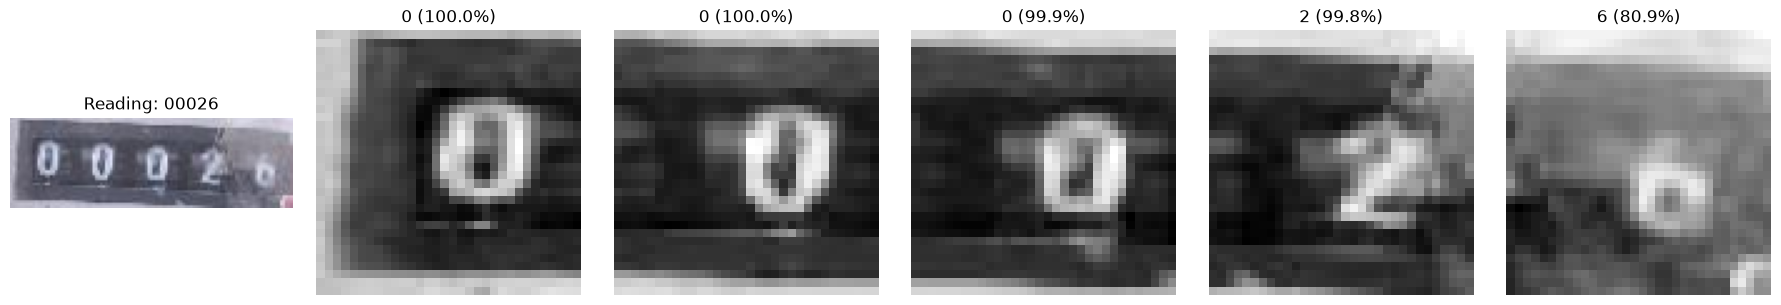


Predicted Reading: 00026
Digit Confidences: [      99.99       99.95       99.88       99.79       80.92]


In [18]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tkinter import Tk, filedialog
import tensorflow as tf
from ultralytics import YOLO

# ========================= CONFIG =========================
NUM_DIGITS = 5           # number of digits to segment and classify
DIGIT_HEIGHT = 32         # size each segmented single-digit crop is resized to
DIGIT_WIDTH = 32

MIN_COMPONENT_AREA_FRAC = 0.01   # component must cover at least 1% of crop area to count as a digit
MAX_COMPONENT_AREA_FRAC = 0.60   # discard components that are implausibly large (merged digits / background)
BOX_PADDING_PX = 2               # padding added around each detected digit box before crop+resize

# EDIT THESE to your actual paths
YOLO_MODEL_PATH = r"best.pt"
CNN_MODEL_PATH = "custom.keras"


# ========================= LOAD MODELS (separate names -- do not both call these "model") =========================
if not os.path.exists(YOLO_MODEL_PATH):
    raise FileNotFoundError(f"Can't find YOLO weights at {YOLO_MODEL_PATH}")
if not os.path.exists(CNN_MODEL_PATH):
    raise FileNotFoundError(f"Can't find CNN model at {CNN_MODEL_PATH}")

yolo_model = YOLO(YOLO_MODEL_PATH)
digit_model = tf.keras.models.load_model(CNN_MODEL_PATH, compile=False)
print(f"Loaded YOLO from {YOLO_MODEL_PATH} and CNN from {CNN_MODEL_PATH}")


# ========================= YOLO: DETECT ROI =========================
def get_meter_roi(image, yolo_model=yolo_model, conf=0.25):
    """Runs YOLO on `image` (path or BGR array), returns the highest-confidence
    bounding box cropped out as a BGR array. None if nothing detected."""
    result = yolo_model.predict(source=image, imgsz=640, conf=conf, verbose=False)[0]

    if len(result.boxes) == 0:
        return None

    boxes = result.boxes.xyxy.cpu().numpy().astype(int)
    confidences = result.boxes.conf.cpu().numpy()
    x1, y1, x2, y2 = boxes[int(np.argmax(confidences))]

    roi = result.orig_img[y1:y2, x1:x2]
    return roi if roi.size > 0 else None


# ========================= DIGIT SEGMENTATION (runs on the YOLO ROI) =========================
def _binarize_for_segmentation(gray_img):
    """Denoise + threshold so digit strokes end up as white (255) on a
    black (0) background, regardless of the original polarity."""
    denoised = cv2.bilateralFilter(gray_img, d=5, sigmaColor=50, sigmaSpace=50)
    _, binary = cv2.threshold(denoised, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    if np.mean(binary == 255) > 0.5:
        binary = cv2.bitwise_not(binary)

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
    return binary


def segment_digit_boxes(gray_img, num_digits=NUM_DIGITS):
    """Returns a list of `num_digits` (x, y, w, h) boxes, left-to-right,
    one per digit. Falls back to equal-width slicing if connected-component
    analysis doesn't cleanly find `num_digits` plausible components."""
    h_img, w_img = gray_img.shape[:2]
    img_area = h_img * w_img

    binary = _binarize_for_segmentation(gray_img)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary, connectivity=8)

    boxes = []
    for label_id in range(1, num_labels):  # skip background label 0
        x, y, w, h, area = stats[label_id]
        area_frac = area / img_area
        if MIN_COMPONENT_AREA_FRAC <= area_frac <= MAX_COMPONENT_AREA_FRAC:
            boxes.append((x, y, w, h))

    if len(boxes) == num_digits:
        boxes.sort(key=lambda b: b[0])
        return boxes

    if len(boxes) > num_digits:
        boxes.sort(key=lambda b: b[2] * b[3], reverse=True)
        boxes = boxes[:num_digits]
        boxes.sort(key=lambda b: b[0])
        return boxes

    # Fallback: equal-width column slicing when segmentation doesn't find enough boxes.
    col_w = w_img // num_digits
    return [(i * col_w, 0, col_w, h_img) for i in range(num_digits)]


def extract_digit_crops(gray_img, num_digits=NUM_DIGITS,
                         target_size=(DIGIT_HEIGHT, DIGIT_WIDTH)):
    """Segments gray_img into num_digits single-digit crops, each resized to
    target_size and normalized to [0, 1], shape (H, W, 1)."""
    h_img, w_img = gray_img.shape[:2]
    boxes = segment_digit_boxes(gray_img, num_digits=num_digits)

    crops = []
    for (x, y, w, h) in boxes:
        x0 = max(0, x - BOX_PADDING_PX)
        y0 = max(0, y - BOX_PADDING_PX)
        x1 = min(w_img, x + w + BOX_PADDING_PX)
        y1 = min(h_img, y + h + BOX_PADDING_PX)

        crop = gray_img[y0:y1, x0:x1]
        if crop.size == 0:
            crop = np.zeros((target_size[0], target_size[1]), dtype=np.uint8)

        crop = cv2.resize(crop, (target_size[1], target_size[0]))
        crop = crop.astype(np.float32) / 255.0
        crops.append(np.expand_dims(crop, axis=-1))

    return crops


# ========================= CNN: READ DIGITS FROM THE ROI =========================
def read_meter_from_roi(roi_bgr, num_digits=NUM_DIGITS, model=digit_model):
    """Takes the YOLO-cropped ROI (BGR array), segments it into individual
    digits, classifies each, and displays the result."""
    gray_img = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2GRAY)
    crops = extract_digit_crops(gray_img, num_digits=num_digits)

    batch = np.stack(crops, axis=0)  # (num_digits, H, W, 1)
    preds = model.predict(batch, verbose=0)
    digit_predictions = np.argmax(preds, axis=1)
    confidences = np.max(preds, axis=1) * 100

    final_reading = "".join(map(str, digit_predictions))

    fig, axes = plt.subplots(1, num_digits + 1, figsize=(3 * (num_digits + 1), 3))
    axes[0].imshow(cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"Reading: {final_reading}")
    axes[0].axis("off")

    for i, crop in enumerate(crops):
        axes[i + 1].imshow(crop.squeeze(), cmap="gray")
        axes[i + 1].set_title(f"{digit_predictions[i]} ({confidences[i]:.1f}%)")
        axes[i + 1].axis("off")

    plt.tight_layout()
    plt.show()

    return final_reading, confidences


# ========================= FILE UPLOAD DIALOG =========================
def upload_image():
    """Open a file dialog and return the selected image path."""
    root = Tk()
    root.withdraw()          # Hide the Tkinter window
    root.attributes("-topmost", True)

    file_path = filedialog.askopenfilename(
        title="Select Meter Image",
        filetypes=[
            ("Image Files", "*.jpg *.jpeg *.png *.bmp *.tif *.tiff"),
            ("All Files", "*.*")
        ]
    )

    root.destroy()

    if not file_path:
        return None

    return file_path


# ========================= MAIN =========================
if __name__ == "__main__":
    image_path = upload_image()

    if image_path is None:
        print("No image selected.")
    else:
        roi = get_meter_roi(image_path, yolo_model=yolo_model, conf=0.25)

        if roi is None:
            print("No meter detected in this image.")
        else:
            reading, confidences = read_meter_from_roi(roi, num_digits=NUM_DIGITS, model=digit_model)
            print(f"\nPredicted Reading: {reading}")
            print("Digit Confidences:", np.round(confidences, 2))